<a id="top"></a>  

<font size ='6'><center><b>Stock Performance with Yahoo! Finance (yfinance)</b></center></font><br>

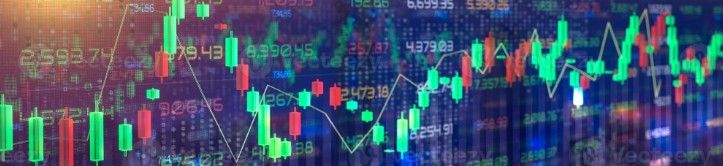

**Yahoo! Finance** https://finance.yahoo.com/ is a free online platform that provides real‑time stock quotes, financial news, market data, press releases, reports and more.  It is widely used by traders, investors, and anyone who wants to follow the stock market or manage a personal portfolio.  

[`yfinance`](#https://pypi.org/project/yfinance/) Python libraries let's programmers fetch almost all availble financial information on any symbol in Yahoo! Finance, such as:

| Yahoo! Finance | |
| :--- | :--- |
|   full name, address, market, sector and currency  |   fundemental indicators:  EPS, PE, beta, ROE, etc.  |
|   historical prices, days high and low  |   technical indicators:  moving averages  |
|   52 week high and low, volume, average volume  |   financial statements:  income statements and cash flow , balance sheets  |
| open, close , dividends, stock splits | and a lot more information |

Enjoy :-)

---

### Table of Content
1.  [**yf.Ticker Method**](#yf_ticker) - retriving stock information<br><br>
    1.1  [Retrieving Parameters for a Symbol](#yf_ticker_parm)<br>
    1.2  [Available Parameters for a Single Symbol](#yf_ticker_parm_all)<br>
    1.3  [All Available Parameters for all Market Type Symbols](#yf_ticker_mrkt)<br>
    1.4  [Financial Statements](#yf_ticker_fin) - balance sheet, cash flow, etc.<br>
    1.5  [Performance Indicators](#yf_ticker_perf) - analyzing performance<br>
    1.6  [Dividends And Stock Splits](#yf_ticker_perf)<br>
<br>
2.  [**yf.download method**](#yf_down) - downloading historical prices<br><br>
    2.1  [Download Historical Prices](#yf_down_hist)<br>
    2.2  [Reduce Multi-Levels To Single-Level Dataframe](#yf_down_single)<br>
    2.3  [End of Week, Month, Quarter, Year Prices](#yf_down_end)<br>
    2.4  [Percent Change](#yf_down_pct)<br>
<br>
3.  [**Financial Markets and Investment Overview**](#stock_markets)<br><br>
    3.1  [Financial Markets](#fin_markets)<br>
    3.2  [Market Indexes](#market_index)<br>
    3.3  [Financial Instruments](#fin_inst)<br>
    3.4  [Investment Instruments](#inv_inst)<br>
    3.5  [Major Financial Events of Past 30 years](#inv_event) - my favorite plot :-)
    
---

<font size="4">References:</font><br>
[yfinance - PyPI](https://pypi.org/project/yfinance/) - `yfinance` documentation<br>
[Yahoo!  Finance](#https://finance.yahoo.com/) - excellent financial website<br>
[Investopedia](#https://www.investopedia.com/) - excellent financial website<br>
[Stock Market 30-yr Dataset (1995-2025)](https://www.kaggle.com/datasets/asimislam/30-yrs-stock-market-data) - 30-year stock market dataset<br>
[Stock Market 30-yr Dataset (1995-2025) Plots](https://www.kaggle.com/code/asimislam/stock-market-30-yr-dataset-1995-2025-plots) - 30-year stock market dataset plots

---
### import libraries and read data

In [1]:
#  Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf    #  Yahoo! Finance

import warnings
warnings.simplefilter(action = "ignore", category = FutureWarning)

#  YahooFinance package versions
print('YahooFinance version: ', yf.__version__)


#  Kaggle directories
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

#  dataset path
path_read = '/kaggle/input/datasets/asimislam/30-yrs-stock-market-data/'

#  step 1:  load datasets
#  - read 30_yr_market_data.csv without index
yf_symbol_data  = pd.read_csv(path_read + '30_yr_symbols_data.csv')
yf_finance_evt  = pd.read_csv(path_read + '30_yr_financial_events.csv')
yf_market_data  = pd.read_csv(path_read + '30_yr_market_data.csv', index_col = 0)

#  step 2:  set "Date" index type as "datetime64[ns]
yf_market_data.set_index(pd.DatetimeIndex(yf_market_data.index), inplace=True)


#  display shapes of dataset files:
print("\ndataset file" + "dataframe".rjust(26) + "shape".rjust(17))
print('-' * 60)
print('30_yr_symbols_data.csv       yf_symbol_data      ', yf_symbol_data.shape)
print('30_yr_financial_events.csv   yf_finance_evt      ', yf_finance_evt.shape)
print(f'30_yr_market_data.csv        yf_market_data       {yf_market_data.shape}, index type:  {yf_market_data.index.dtype}',)

YahooFinance version:  0.2.66
/kaggle/input/datasets/asimislam/30-yrs-stock-market-data/30_yr_symbols_data.csv
/kaggle/input/datasets/asimislam/30-yrs-stock-market-data/30_yr_financial_events.csv
/kaggle/input/datasets/asimislam/30-yrs-stock-market-data/30_yr_market_data.csv

dataset file                 dataframe            shape
------------------------------------------------------------
30_yr_symbols_data.csv       yf_symbol_data       (56, 6)
30_yr_financial_events.csv   yf_finance_evt       (11, 3)
30_yr_market_data.csv        yf_market_data       (9229, 56), index type:  datetime64[ns]


---

<font size="5">A few things before we get started:</font>
- any valid **Yahoo! Finance** financial symbol (market indexes, stocks, bonds, funds, etc.) can be used.  Typically, Yahoo! Finance includes carat "`^`" for markets and equal sign "`=`" for futures<br>
- **Symbol** and **Ticker** are used interchangeably for any financial symbol, [Financial Instruments](#fin_inst) or [Investment Instruments](#inv_inst) investment symbol, e.g.  markets, equities, currencies, commodities, futures, and bonds.<br>
-  **parameter** is any element with a value that is available in `yf.Ticker`
- **Market**, **Market Index** and **Index** are used interchangeably for [Financial Markets](#fin_markets) or [Market Indexes](#market_index).  **Market Indicator** measure volitility<br>
- **Market Indicator**  measures the market's expectation of 30-day volatility for the S&P 500.  **CBOE Volatility Index (^VIX)** is the most common market indicator and is generally known as **volitility**, **volitility indicator**, **volitility index** or simply as **VIX**.
- `yfinance` is a Python library and is not an official product from Yahoo
- **note:** this notebook is only a helpful tool and not financial advice!

[go to top](#top)

---

<a id="yf_ticker"></a>
# 1.  yf.Ticker Method
`yf.Ticker` can be  used to retrieve financial parameters, financial statements and performance indicators.

1.1  [Retrieving Parameters for a Symbol](#yf_ticker_parm)<br>
1.2  [Available Parameters for a Symbol](#yf_ticker_parm_all)<br>
1.3  [All Available Parameters for all Market Type Symbols](#yf_ticker_mrkt)<br>
1.4  [Financial Statements](#yf_ticker_fin)<br>
1.5  [Performance Indicators](#yf_ticker_perf)<br>
1.6  [Dividends And Stock Splits](#yf_ticker_perf)<br>

<a id="yf_ticker_parm"></a>
## 1.1  Retrieving Parameters for a Symbol
Use `yf.Ticker` to retrive a few basic financial parameters for **Walmart Inc.**

-  **parameter** is any element with a value that is available in `yf.Ticker("SYMBOL").info`

<font size="3">BASIC PARAMETERS:</font>

In [2]:
WMT = yf.Ticker('WMT').info  # returns dictionary (key-value pair)

print(f"longName:              {WMT['longName'] :<20}")
print(f"currentPrice:          {WMT['currentPrice'] :<20}")
print(f"fiftyTwoWeekHigh:      {WMT['fiftyTwoWeekHigh'] :<20}")
print(f"averageVolume:         {WMT['averageVolume'] :<20}")
print(f"forwardPE:             {WMT['forwardPE'] :<20}")
print(f"epsCurrentYear:        {WMT['epsCurrentYear'] :<20}")
print(f"beta:                  {WMT['beta'] :<20}")
print(f"number of parameters:  {len(WMT.keys()):<20}")

longName:              Walmart Inc.        
currentPrice:          119.02              
fiftyTwoWeekHigh:      134.69              
averageVolume:         30879046            
forwardPE:             36.24007            
epsCurrentYear:        2.91977             
beta:                  0.657               
number of parameters:  183                 


<font size="3">LIST OF WALMART INC. OFFICERS:</font>

In [3]:
pd.DataFrame(WMT['companyOfficers'])

,maxAge,name,age,title,yearBorn,fiscalYear,totalPay,exercisedValue,unexercisedValue
0,1,Mr. John R. Furner,50.0,"President, CEO & Director",1975.0,2025,4327422.0,0,0
1,1,Mr. John David Rainey Jr.,55.0,Executive VP & CFO,1970.0,2025,3534727.0,0,0
2,1,Mr. Suresh Kumar Ph.D.,60.0,"Executive VP, Global CTO & Chief Development O...",1965.0,2025,3709340.0,0,0
3,1,Mr. C. Douglas McMillon,59.0,Executive Officer & Director,1966.0,2025,6249434.0,0,0
4,1,Mr. Christopher Nicholas,47.0,President & CEO of Walmart International,1978.0,2025,3255161.0,0,0
5,1,Mr. Dwayne Milum,NaN,"Senior VP, Controller & Principal Accounting O...",NaN,2025,NaN,0,0
6,1,Ms. Stephanie Wissink,NaN,Senior Vice President of Investor Relations,NaN,2025,NaN,0,0
7,1,Ms. Elisebeth B. Collins,NaN,"Executive VP, Global Chief Ethics & Compliance...",NaN,2025,NaN,0,0
8,1,Ms. Allyson Park,NaN,Senior VP & Chief Communications Officer,NaN,2025,NaN,0,0
9,1,Ms. Donna Catherine Morris,58.0,Executive VP & Chief People Officer,1967.0,2025,NaN,0,0


<font size="3">PARAMETERS ACROSS ALL MARKET TYPES:</font><br>
`yf.Ticker` works for any market type symbol.  Displaying `averageVolume` for symbols in each market type:

In [4]:
print("MARKET TYPE".rjust(30) + "SYMBOL".rjust(11) + "PARAMETER".rjust(15) + "VALUE".rjust(20))
print('-' * 76)   #  print header

#  retrive first symbol in each market type and output parameter value
for mrkt in yf_symbol_data['TYPE'].unique():
    symb = yf_symbol_data.loc[yf_symbol_data['TYPE'] == mrkt, 'SYMBOL'].values[0]
    print(f"{mrkt:>30}  {symb :>8}    'averageVolume'   {yf.Ticker(symb).info['averageVolume'] :>14}")
    
print('-' * 76)  #  print footer

                   MARKET TYPE     SYMBOL      PARAMETER               VALUE
----------------------------------------------------------------------------
                  Market Index    ^GDAXI    'averageVolume'         66004006
              Market Indicator      ^VIX    'averageVolume'                0
                 Equity: Stock      AMZN    'averageVolume'         48561821
                   Equity: ETF      NUGT    'averageVolume'           801560
           Equity: Mutual Fund     FSENX    'averageVolume'                0
                      Currency   BTC-USD    'averageVolume'      43390657234
        Commodity: Agriculture      CC=F    'averageVolume'            10348
             Commodity: Energy      BZ=F    'averageVolume'            68243
  Commodity: Industrial Metals     ALI=F    'averageVolume'                7
    Commodity: Precious Metals      GC=F    'averageVolume'             3281
           U.S. Treasury Bonds      ^IRX    'averageVolume'                0

<a id="yf_ticker_parm_all"></a>
## 1.2  Available Parameters for a Single Symbol
Use `yf.Ticker` to retrive all the available financial parameters for **Walmart Inc.**  Convert `yf_ticker_WMT` dictionary to dataframe.

-  **parameter** is any element with a value that is available in `yf.Ticker`
-  **Walmart Inc.** is of market type **"Equity: Stock "**

<font size ='2'><b><font color="purple">note: full output not displayed to save space</font></b></font>

In [5]:
#  create dataframe from dictionary key-value pair
yf_ticker_WMT = pd.DataFrame(
    {'parameters' : yf.Ticker('WMT').info.keys(),      #  dict key names
     'values'     : yf.Ticker('WMT').info.values()})   #  dict values

#  print sample of dataframe
print(f"{len(yf.Ticker('WMT').info.keys())} yfinance parameters are available for Walmart Inc.")
yf_ticker_WMT.sample(7)


183 yfinance parameters are available for Walmart Inc.


,parameters,values
128,quoteSourceName,Nasdaq Real Time Price
160,fiftyTwoWeekChangePercent,36.0384
169,epsForward,3.28421
65,profitMargins,0.0307
76,shortPercentOfFloat,0.0109
137,messageBoardId,finmb_313055
152,regularMarketDayRange,118.02 - 121.3


<a id="yf_ticker_mrkt"></a>
## 1.3  All Available Parameters for all Market Type Symbols
Retrieve all the available parameters for the following market types:

|  market types | | | |
| :--- | :--- | :--- | :--- |
| Market Index | Market Indicator | Equity: Stock | Equity: ETF |
| Equity: Mutual Fund | Currency | Commodity: Agriculture | Commodity: Energy |
| Commodity: Industrial Metals | Commodity: Precious Metals | U.S. Treasury Bonds' |

<br>

Creating dataframe requires all rows to be the same length, hence following steps are required  for each market type:

-  **parameter** is any element with a value that is available in `yf.Ticker`
-  each **symbol** represents one of the **market types**

1. finding the **maximum number** of paramters for a market type
2. create dataframe with **row count = max parameters**
3. fill in the dataframe
    * 3a:  retrive first symbol of each market type
    * 3b:  use `yf.Ticker(symb).info.keys()` to retrive the parameter list
    * 3c:  pad length of parameter list to equal maximum rows
    * 3d:  add parameter list of length maxP to dataframe

<font size ='2'><b><font color="purple">note: full output not displayed to save space</font></b></font>

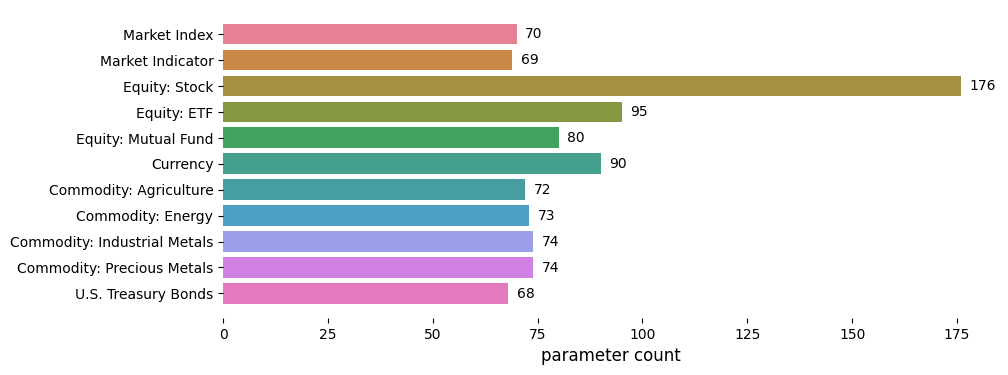

In [6]:
#  step 1:  find maximum number of paramters
#           SYMBOL/TYPE with the most parameters
#-----------------------------------------
#  unique market types
market_type = yf_symbol_data['TYPE'].unique()

#  initialize parameter count list
max_params_list = []

#  retrive first symbol in of market type & append to list
for mrkt in market_type:
    symb = yf_symbol_data.loc[yf_symbol_data['TYPE'] == mrkt, 'SYMBOL'].values[0]
    max_params_list.append(len(yf.Ticker(symb).info.keys()))

#  maximum number of parameters in max_params_list list
max_param_value = max(max_params_list)   


#  plot parameter count per market type
plt.figure(figsize = (10, 4))
sns.barplot(x = max_params_list, y = market_type, hue = market_type, legend = False)
plt.xlabel('parameter count', fontsize = 12)
plt.box(False)

# annotate parameter count plot
for mkt, cnt in zip(list(market_type), max_params_list):
    x = cnt    #  x-axis parameter count
    y = mkt    #  y-axis market type
    txt = cnt  #  text   parmater count
    plt.text(cnt+2, mkt, cnt, ha ='left', va = 'center')
plt.plot()


#  step 2:  create dataframe with row count = max parameters length
#-----------------------------------------
yf_available_parameters = pd.DataFrame(index = range(max_param_value), columns = market_type)

In [7]:
#  step 3:  fill in the dataframe
#-----------------------------------------
for mrkt in yf_symbol_data['TYPE'].unique():
    #  a)  retrive first symbol of each market type
    symb = yf_symbol_data.loc[yf_symbol_data['TYPE'] == mrkt, 'SYMBOL'].values[0]
    #  b)  use `yf.Ticker(symb).info.keys()` to retrive the parameter list
    params = list(yf.Ticker(symb).info.keys())
    #  c)  pad length of parameter list to equal maximum rows
    params = params + ([""] * (max_param_value - len(params)))
    #  d)  add parameter list of length max_param_value to dataframe
    yf_available_parameters[mrkt] = params

yf_available_parameters.head(7)

,Market Index,Market Indicator,Equity: Stock,Equity: ETF,Equity: Mutual Fund,Currency,Commodity: Agriculture,Commodity: Energy,Commodity: Industrial Metals,Commodity: Precious Metals,U.S. Treasury Bonds
0,maxAge,maxAge,address1,phone,address1,website,maxAge,maxAge,maxAge,maxAge,maxAge
1,priceHint,priceHint,city,longBusinessSummary,address2,companyOfficers,priceHint,priceHint,priceHint,priceHint,priceHint
2,previousClose,previousClose,state,companyOfficers,address3,blockNumber,previousClose,previousClose,previousClose,previousClose,previousClose
3,open,open,zip,executiveTeam,longBusinessSummary,blockReward,open,open,open,open,open
4,dayLow,dayLow,country,maxAge,companyOfficers,blockRewardReduction,dayLow,dayLow,dayLow,dayLow,dayLow
5,dayHigh,dayHigh,phone,priceHint,executiveTeam,netHashesPerSecond,dayHigh,dayHigh,dayHigh,dayHigh,dayHigh
6,regularMarketPreviousClose,regularMarketPreviousClose,website,previousClose,maxAge,name,regularMarketPreviousClose,regularMarketPreviousClose,regularMarketPreviousClose,regularMarketPreviousClose,regularMarketPreviousClose


**NOTE:**  Some symbols in the same market types may have different number of parameters availble.  For example:   Nvidia has a few more parameters available:

In [8]:
print('Nvidia has {} "info" paramters'.format(len(yf.Ticker('NVDA').info.keys())))
print('Amazon has {} "info" paramters'.format(len(yf.Ticker('AMZN').info.keys())))

Nvidia has 185 "info" paramters
Amazon has 176 "info" paramters


<a id="yf_ticker_fin"></a>
## 1.4  Financial Statements
Displaying financial statement information for **Walmart Inc.** for last years using  `.financials`, `balance_sheet` and `cash_flow` methods.

Companies provide four types of financial statements every quarter and annually:
-  **Balance Sheet:** Shows a company's assets, liabilities, and equity at a specific point in time. 
-  **Income Statement:** Reports a company's revenues, expenses, and net income for a specific period. 
-  **Statement of Cash Flows:** Details the company's cash inflows and outflows, categorized into operating, investing, and financing activities. 
- **Statement of Retained Earnings:** Displays changes in retained earnings over a period, providing insights into a company's financial performance.

**note:**  `financials` method contains almost all the information for the four financial statements.

<font size ='2'><b><font color="purple">note: full output not displayed to save space</font></b></font>

In [9]:
# disable scientific notation
pd.set_option('display.float_format', '{:,.2f}'.format)


#  financial statements
wmt_financials    = yf.Ticker('WMT').financials
wmt_balance_sheet = yf.Ticker('WMT').balance_sheet
wmt_cash_flow     = yf.Ticker('WMT').cash_flow

#  print sample of financial statements 
print('\t\t~~~ sample of financial statements ~~~')
print('\n--- financials: ---   \n', wmt_financials[wmt_financials.columns[:2]].head(5))
print('\n--- balance sheet: ---\n', wmt_balance_sheet[wmt_balance_sheet.columns[:2]].head(5))
print('\n--- cash flow: ---    \n', wmt_cash_flow[wmt_cash_flow.columns[:2]].head(5))


# reset scientific notation
pd.reset_option('display.float_format')

		~~~ sample of financial statements ~~~

--- financials: ---   
                                               2026-01-31        2025-01-31
Tax Effect Of Unusual Items                         0.00              0.00
Tax Rate For Calcs                                  0.24              0.23
Normalized EBITDA                      46,471,000,000.00 42,010,000,000.00
Total Unusual Items                                  NaN               NaN
Total Unusual Items Excluding Goodwill               NaN               NaN

--- balance sheet: ---
                               2026-01-31        2025-01-31
Ordinary Shares Number  7,969,000,000.00  8,024,000,000.00
Share Issued            7,969,000,000.00  8,024,000,000.00
Net Debt               34,035,000,000.00 30,030,000,000.00
Total Debt             67,095,000,000.00 60,114,000,000.00
Tangible Book Value    70,882,000,000.00 62,221,000,000.00

--- cash flow: ---    
                                     2026-01-31         2025-01-31
Free Cash Flow

<a id="yf_ticker_perf"></a>
## 1.5  Performance Indicators
Several widely used indicators help investors evaluate how a stock is performing.  These metrics highlight profitability, valuation, growth potential, and market behavior, giving a more complete picture of a company’s financial health and stock momentum.

- **Fundamental Performance Indicators:**  measure a company’s financial strength and long‑term value
- **Technical Performance Indicators:**  help analyze price trends, momentum, and market sentiment

|  |  FUNDAMENTAL PERFORMANCE INDICATORS |  | TECHNICAL PERFORMANCE INDICATORS |
| :--- | :--- | :--- | :--- |
|  EPS | Earnings Per Share:  Profit allocated to each outstanding share; a core measure of profitability |  MA | Moving Averages: Identify trend direction by smoothing price data |
|  P/E | Price-to-Earnings Ratio:  Compares share price to earnings; helps assess valuation | RSI |  Relative Strength Index: Measures momentum and overbought/oversold conditions (*requires caluclation*) |
|  ROE | Return on Equity:  Profitability relative to shareholder equity; shows how efficiently a company uses capital |  MACD | Moving Average Convergence Divergence:  Tracks trend changes and momentum (*requires caluclation*) |
| FCF | Free Cash Flow: Cash available after expenses and investments; important for sustainability |  | Volume Indicators: Show trading activity and confirm price moves |
|   D/E | Debt-to-Equity Ratio: Measures leverage and financial risk | | Volatility Indicators: Gauge expected market volatility (e.g., VIX: above 30 = fear & uncertainty, below 20 = stability)|
| | Dividend Yield: Annual dividends relative to share price; key for income investors | |
| P/B | Price-to-Book Ratio: Compares market value to book value; useful for value investing | |
| EBIT | Earnings Before Interest, Taxes, Depreciation and Amortization | |
| EBIT margin | EBIT margin is a profitability ratio that shows how much of a company’s revenue turns into operating profit | |
| Gross margin | Gross margin is the percentage of revenue retained after labor and materials expenses | |

In [10]:
#  step 1:  select a few "Equity: Stock" symbols 
perf_symb = ['GOOGL', 'JPM', 'MA', 'NVDA', 'WMT']

#  step 2:  select the performance indicators
perf_indicators = ['longName', 'sector', 'epsCurrentYear', 'trailingPE', 'forwardPE', 'returnOnEquity', 'freeCashflow', 'debtToEquity', 'priceToBook', 'ebitda', 'ebitdaMargins', 'grossMargins', 'twoHundredDayAverage']

#  step 3:  create dataframe for performance indicators
yf_performance_indicators = pd.DataFrame(index = perf_indicators, columns = perf_symb)

#  step 4:  fill out dataframe
#  o  symbol information with yf.Ticker() 
#  o  loop through each symbol, retrieve paramter and values
for psymb in perf_symb:
    plist  = []                #  initialize list
    ticker = yf.Ticker(psymb)  #  get ticker info
    
    #  append parameters to list
    for pparm in perf_indicators:
        try:
            plist.append(ticker.info[pparm])
        except:
            plist.append("")
    
    #  assign parameters list to symbol columns
    yf_performance_indicators[psymb] = plist
    
yf_performance_indicators

,GOOGL,JPM,MA,NVDA,WMT
longName,Alphabet Inc.,JPMorgan Chase & Co.,Mastercard Incorporated,NVIDIA Corporation,Walmart Inc.
sector,Communication Services,Financial Services,Financial Services,Technology,Consumer Defensive
epsCurrentYear,11.57025,21.90712,19.59657,8.28925,2.91977
trailingPE,27.844587,14.30654,30.025408,35.244896,43.59707
forwardPE,22.426586,12.19803,21.917364,15.519648,36.24007
returnOnEquity,0.35705,0.16134,2.09915,1.01485,0.21847
freeCashflow,38088376320,,16269375488,58128998400,10554250240
debtToEquity,16.133,,256.042,7.255,64.443
priceToBook,8.761971,2.256591,57.351513,26.684177,9.520838
ebitda,150175006720,,20544000000,133230002176,44027998208


###  example: EPS and PE performance indicator analysis 
Quick overview of EPS and PE performance indicators:
- **epsGrowth:**  values >15% are good and indicates consistent growth.  **JPM**  and **MA** have good growth potential
-  **trailingPE:**  values <25% are good and indicate signs of undervaluation.  **JPM** is undervalued
-  **forwardPE:**  values <15% are good and indicates future growth.  Again **JPM**

<font size ='3'><b><font color="darkred">note:  Analysis is very basic not financial advise!</font></b></font>

<a id="yf_dividends"></a>
## 1.6.  Dividends and Stock Splits
Dividends and Stock Splits can be downloaded using the `yf.Ticker(symb).actions` method.

    - yf.Ticker(symbol).actions['Dividends']
    - yf.Ticker(symbol).actions['Stock Splits']


###  1.6.1  Dividends
Dividends are periodic payments made to shareholders from corporate profits in order to make a stock more attractive to investors.  But it may also signal that a company isn't doing enough to generate better returns.  Dividend distribution is determined by the company's board of directors and many companies do not pay dividends.

- A company’s **dividend** or **dividend rate** is expressed as a dollar figure and is the combined total of dividend payments expected.
- The **dividend yield** is expressed as a percentage and represents the ratio of a company’s annual dividend compared to its share price.

In [11]:
symb = 'ABEV'

#  dividends
print('full name of company:        {}'.format(yf.Ticker(symb).info['longName']))
print('dividend or dividend rate:   ${}'.format(yf.Ticker(symb).info['dividendRate']))
print('dividend yield:              {}%'.format(yf.Ticker(symb).info['dividendYield']))

full name of company:        Ambev S.A.
dividend or dividend rate:   $0.31
dividend yield:              11.47%


**Calender** of financial events for a company.

In [12]:
#  calender
yf.Ticker(symb).calendar

{'Dividend Date': datetime.date(2026, 1, 9),
 'Ex-Dividend Date': datetime.date(2025, 12, 22),
 'Earnings Date': [datetime.date(2026, 5, 5)],
 'Earnings High': None,
 'Earnings Low': None,
 'Earnings Average': None,
 'Revenue High': 22867000000,
 'Revenue Low': 21622203000,
 'Revenue Average': 22437973230}

###  1.6.2  Stock Split
A stock split happens when a company divides its stock into multiple shares, effectively lowering the price of each share without changing the company's market value.

- **stock split** - divide stock by a split factor into multiple shares, resulting in a lower price per share
- **reverse stock split** - consolidate stock by a split factor by combining multiple shares in to one, resulting in a higher price per share
- **stock factor** - ratio that determines by how much a company divides or consolidates the existing shares during a stock split.  Value of investment stays the same

In [13]:
#  splits
lastSplitDate = yf.Ticker(symb).info['lastSplitDate']
lastSplitDate = pd.to_datetime(lastSplitDate).strftime('%Y-%m-%d')
print('full name of company:        {}'.format(yf.Ticker(symb).info['longName']))
print('stock split date:            {}'.format(lastSplitDate))
print('stock split factor           {}'.format(yf.Ticker(symb).info['lastSplitFactor']))

full name of company:        Ambev S.A.
stock split date:            1970-01-01
stock split factor           5:1


###  Plots of Dividends & Stock Splits

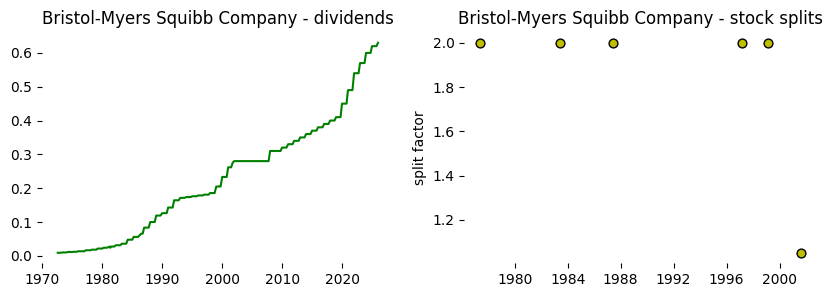

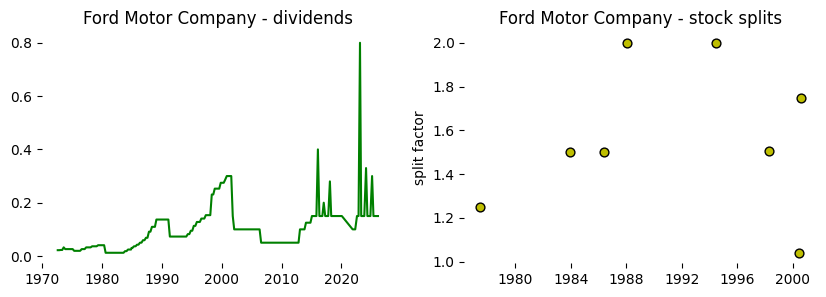

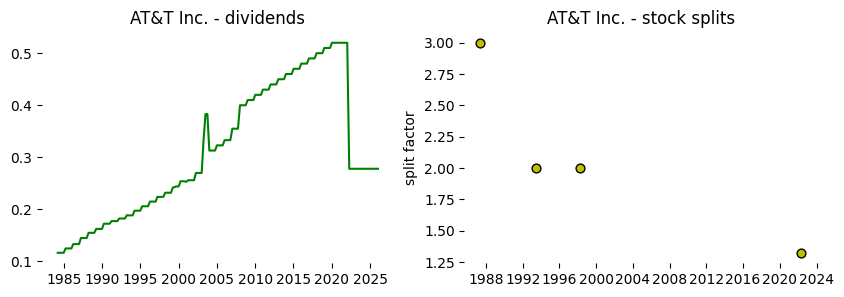

In [14]:
#  plot stocks with dividend and splits
#=========================================
dividend_stocks = ['BMY', 'F', 'T']

for symb in dividend_stocks:
    #  get history
    symb_name = yf.Ticker(symb).info['shortName']
    dvd = yf.Ticker(symb).actions['Dividends']
    spl = yf.Ticker(symb).actions['Stock Splits']
    
    #  get non-zero values
    dvd = dvd[dvd.values != 0]
    spl = spl[spl.values != 0]

    #  plot dividends and splits
    plt.figure(figsize = (10, 3))
    plt.subplot(121)
    plt.plot(dvd.index, dvd.values, color = 'g')
    plt.title(f'{symb_name} - dividends')
    plt.box(False)
    plt.subplot(122)
    plt.scatter(spl.index, spl.values, color = 'y', s = 40, edgecolors = 'k')
    plt.title(f'{symb_name} - stock splits')
    plt.ylabel('split factor')
    plt.box(False)
    plt.show()

[go to top](#top)

---
<a id="yf_down"></a>
# 2.  yf.download Method
`yf.download` method allows user to download historical prices for multiple symbols.  It is a very fast and efficient process...the **[Stock Market 30-yr Dataset (1995-2025)](https://www.kaggle.com/datasets/asimislam/30-yrs-stock-market-data)** dateset with 30 years dailty closing prices of over 50 symbols took a few minutes to download.

Only catch is that the downloaded dataframe create by `yf.download` is multi-level.  Steps to convert it to a single-level dataframe with the **Close** prices is simple and shown in the code below.

2.1  [Download Historical Prices](#yf_down_hist)<br>
2.2  [Reduce Multi-Levels To Single-Level Dataframe](#yf_down_single)<br>
2.3  [Retrieve End Of Week, Month, Year Prices](#yf_down_end)<br>
2.4  [Dataframe with Percent Change](#yf_down_pct)<br>

<a id="yf_down_hist"></a>
##  2.1  Download Historical Prices
Download historical prices for various symbols 2025 using date range.

In [15]:
#  step 1:  set variables for "yf.download"
#-----------------------------------------
#  step 1a:  SELECT SYMBOLS, one for each market type
symbols = ['^GSPC', '^VIX', 'NVDA', 'SPY', 'FSENX', 'BTC-USD', 'ZL=F', 'CL=F', 'HG=F', 'GC=F', '^TNX']

#  step 1b:  remove any whitespaces from SYMBOLS
symbols = [i.strip() for i in symbols]      # strip whitespaces
symbols = [x.upper() for x in symbols]      # uppercase

print('download historical prices for following symbols using yf.download:\n', symbols)

download historical prices for following symbols using yf.download:
 ['^GSPC', '^VIX', 'NVDA', 'SPY', 'FSENX', 'BTC-USD', 'ZL=F', 'CL=F', 'HG=F', 'GC=F', '^TNX']


In [16]:
#  step 2:  download historical data with "yf.download"
#------------------------------------------------------
start_date  = '2023-01-03'   #  start date
end_date    = '2025-12-31'   #  end date
yf_interval = "1d"           #  daily prices

yf_historical_data  = yf.download(
        tickers     = symbols,     #  string or list
        start       = start_date,  #  start date string (YYYY-MM-DD)
        end         = end_date,    #  end date string (YYYY-MM-DD)
        interval    = yf_interval, #  1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        group_by    = 'ticker',    #  group by ticker
        rounding    = True,        #  round values to 2 decimal places
        auto_adjust = True)        #  adjust all OHLC automatically
#------------------------------------------------------

yf_historical_data.head(3)

[*********************100%***********************]  11 of 11 completed


Ticker        HG=F                                  ^VIX                       \
Price         Open   High     Low   Close  Volume   Open   High    Low  Close   
Date                                                                            
2023-01-03  3.8325  3.842  3.7615  3.7660  1032.0  23.09  23.76  22.73  22.90   
2023-01-04  3.7360  3.752  3.7275  3.7395   663.0  22.93  23.27  21.94  22.01   
2023-01-05  3.8005  3.818  3.8005  3.8180   367.0  22.20  22.92  21.97  22.46   

Ticker             ...     SPY                                       BTC-USD  \
Price      Volume  ...    Open    High     Low   Close      Volume      Open   
Date               ...                                                         
2023-01-03    0.0  ...  368.48  370.45  362.21  365.07  74850700.0  16688.85   
2023-01-04    0.0  ...  367.33  369.92  364.29  367.89  85934100.0  16680.21   
2023-01-05    0.0  ...  365.93  366.05  363.10  363.69  76970500.0  16863.47   

Ticker                                                 
Price           High       Low     Close       Volume  
Date                                                   
2023-01-03  16760.45  16622.37  16679.86  13903079207  
2023-01-04  16964.59  16667.76  16863.24  18421743322  
2023-01-05  16884.02  16790.28  16836.74  13692758566  

[3 rows x 55 columns]

<a id="yf_down_single"></a>
##  2.2  Reduce Multi-Levels to Single-Level Dataframe
`yf.download` downloads historical prices in a multi-level dataframe.  Following cleanup is required:
- select 'Close' (price at market close) column only
- remove the dataframe multi-index
- reorder SYMBOLS column names
- rename column names from SYMBOLS to NAME

In [17]:
#  step 3a:  select 'Close' (price at market close) column only
yf_historical_data = yf_historical_data.iloc[:, yf_historical_data.columns.get_level_values(1) == 'Close']

#  step 3b:  remove the dataframe multi-index
yf_historical_data.columns = yf_historical_data.columns.droplevel(1)

#  step 3c:  reorder SYMBOLS column names
yf_historical_data = yf_historical_data[symbols]

#  step 3d:  rename column names from SYMBOLS to NAME
update_names = dict(zip(list(yf_symbol_data['SYMBOL']), list(yf_symbol_data['NAME'])))
yf_historical_data.rename(columns = update_names, inplace = True)

yf_historical_data.sample(7)

Ticker,S&P500,CBOE Volitility,Nvidia,S&P 500 ETF,Fidelity Energy Portfolio,Bitcoin,Soybeans,Crude Oil-WTI,Copper,Gold,T-Note 10 Years
Date,,,,,,,,,,,
2025-08-09,NaN,NaN,NaN,NaN,NaN,116500.36,NaN,NaN,NaN,NaN,NaN
2024-11-06,5929.04,16.27,145.55,580.63,59.00,75639.08,46.34,71.69,4.2225,2667.6,4.426
2024-07-25,5399.22,18.46,112.23,527.31,60.32,65777.23,45.81,78.28,4.1125,2351.9,4.256
2023-12-04,4569.78,13.08,45.48,442.66,53.53,41980.10,51.19,73.04,3.8205,2024.1,4.288
2025-06-07,NaN,NaN,NaN,NaN,NaN,105615.62,NaN,NaN,NaN,NaN,NaN
2023-10-28,NaN,NaN,NaN,NaN,NaN,34089.57,NaN,NaN,NaN,NaN,NaN
2023-09-25,4337.44,16.90,42.19,418.96,57.88,26298.48,58.75,89.68,3.6495,1916.6,4.542


<a id="yf_down_end"></a>
##  2.3  End of Week, Month, Quarter, Year Prices
Typically, financial analysis requires looking at trends over a long period of time.  Daily prices are not necessary and the dataframe can be reduced to end-of-month, end-of-quarter, end-of-year values without losing vital information.

Dataframes with dates can be reduces using:
- `resample()` method with `'W-FRI', 'ME', 'QE', 'YE'` and `.last()`.  
- `MS`, `YS` denote month start, year start and should be used with `.first()`
- for more frequency options, search for *"python resample frequency options list"*

**note:**  **[percent change](#yf_down_pct)** provides the best trend information.

In [18]:
#  select few symbols for plotting
symb = ['S&P500', 'Nvidia', 'Bitcoin', 'Crude Oil-WTI', 'Gold', 'T-Note 10 Years']
yf_historical_data = yf_historical_data[symb]


#-----------------------------------------
#  FUNCTION:  plotSymbols
#  o subplot with lineplot and boxplot
#-----------------------------------------
def plotSymbols(yf_data, ylabel = ''):
    #  select symbols
    symb = ['S&P500', 'Nvidia', 'Bitcoin', 'Crude Oil-WTI', 'Gold', 'T-Note 10 Years']
    yf_data = yf_data[symb]
    
    #  set xticks using date (index) series data
    sta_date = int(str(min(yf_data.index)).split('-')[0])
    end_date = int(str(max(yf_data.index)).split('-')[0])
    dates    = np.linspace(sta_date, end_date + 1, num = 4, dtype = int)
            
    xticks_ticks = [f'{x}-01' for x in dates]
    xticks_label = [x.split('-')[0] for x in xticks_ticks]
    
    # subplots:  lineplot and boxplot
    plt.figure(figsize = (10, 6))
    plt.subplot(121)
    sns.lineplot(data = yf_data, dashes = False)
    plt.xlabel('')
    plt.ylabel(ylabel)
    plt.legend(frameon = False)
    plt.xticks(xticks_ticks, xticks_label)
    plt.box(False)
    
    plt.subplot(122)
    sns.boxplot(yf_data)
    plt.xlabel('')
    plt.xticks(rotation = 90)
    plt.box(False)
    
    plt.tight_layout()
    plt.show()
#-----------------------------------------

###  end of week

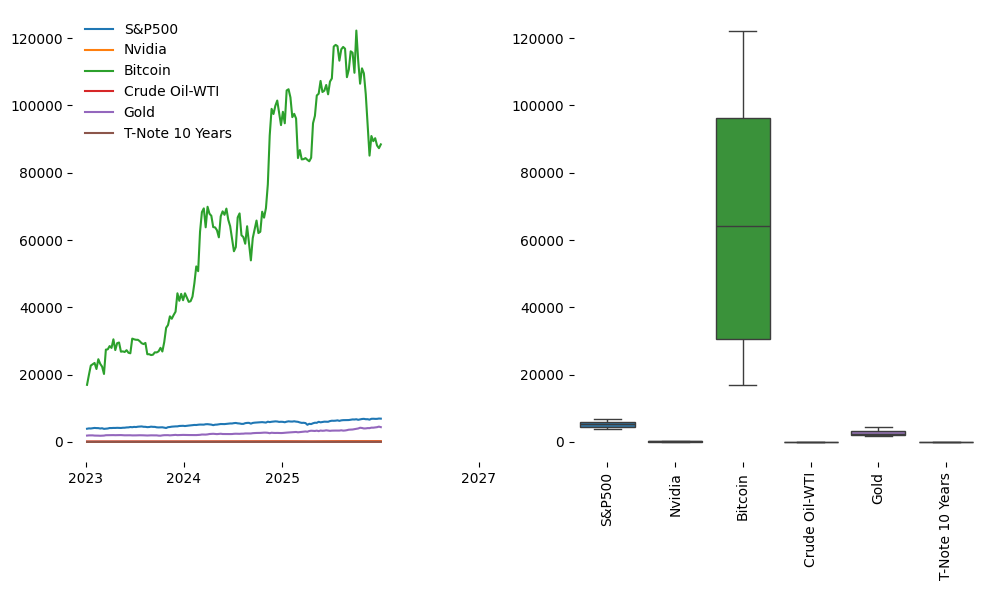

In [19]:
#  end of week values
yf_hist_end_of_week_data = yf_historical_data.resample('W-FRI').last()
plotSymbols(yf_hist_end_of_week_data)  #  call plot function

###  end of month

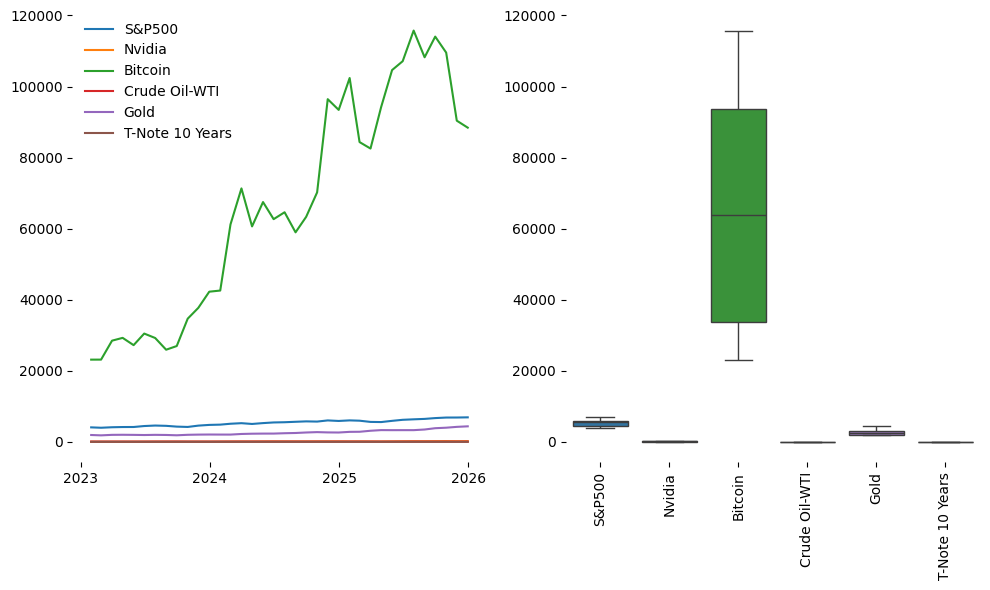

In [20]:
#  end of month values
yf_hist_end_of_month_data = yf_historical_data.resample('ME').last()
plotSymbols(yf_hist_end_of_month_data)  #  call plot function

###  end of quarter

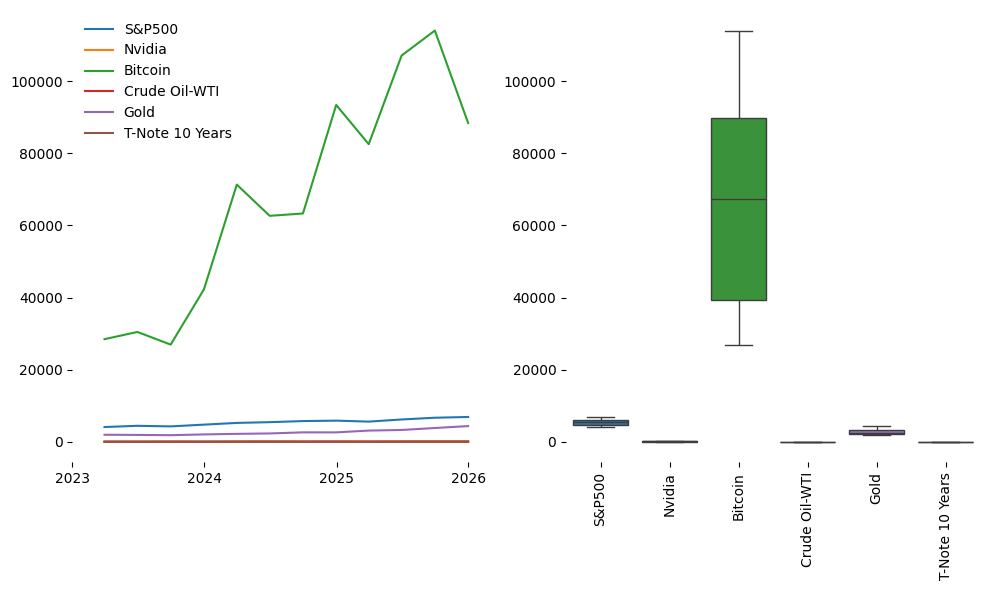

In [21]:
#  end of quarter values
yf_hist_end_of_quarter_data = yf_historical_data.resample('QE').last()
plotSymbols(yf_hist_end_of_quarter_data)  #  call plot function

###  end of year

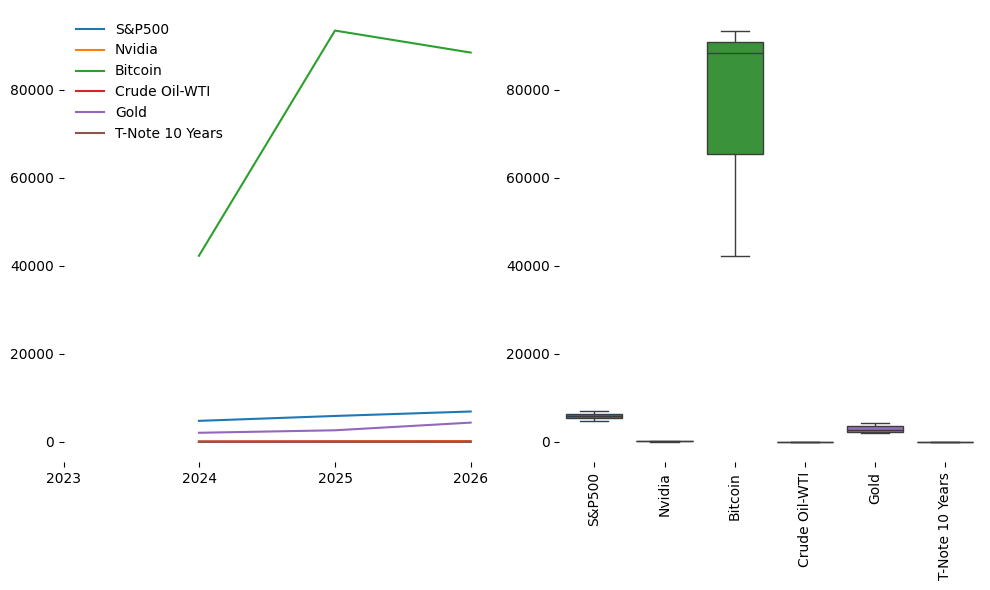

In [22]:
#  end of year values
yf_hist_end_of_year_data = yf_historical_data.resample('YE').last()
plotSymbols(yf_hist_end_of_year_data)  #  call plot function

<a id="yf_down_pct"></a>
##  2.4  Percent Change
Percent change is an incredibly useful tool for financial analysis and gives the most informative overview of performance over time.  Pandas conveniently provides following methods for percent change calculations:
- `.pct_change()` to calculate percent changes
- `.cumsum()` to sum the cummulative percent changes
- `x 100` to get the numerical numbers

Percent change provides a normalized view of the data, and we see that **Nvidia** actually outperformed **Bitcoin**.

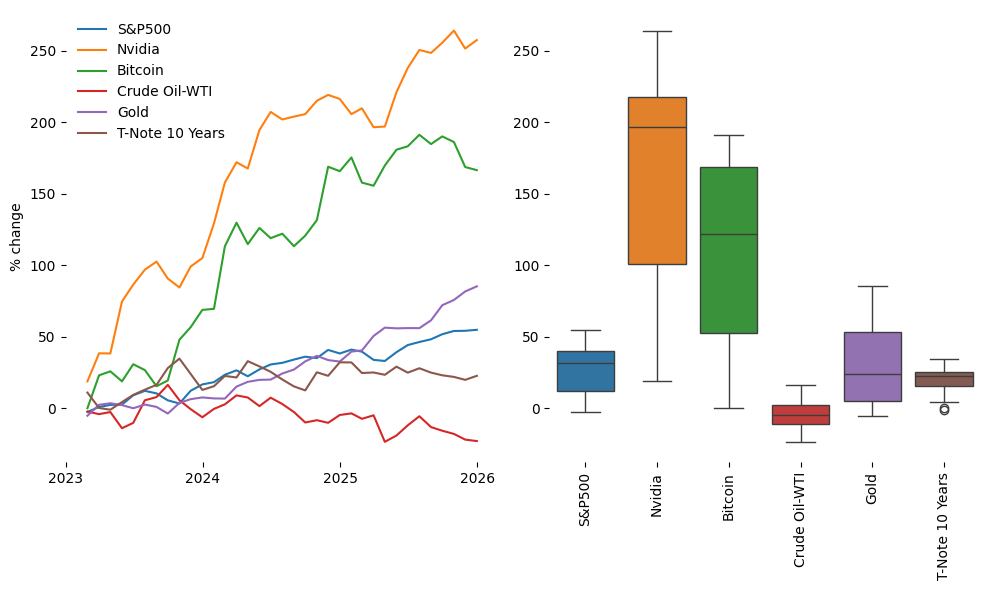

In [23]:
yf_hist_end_of_month_percent_change_data = yf_hist_end_of_month_data.pct_change().cumsum()*100

#  call plotSymbols with unit = '% change' (for plt.ylabel)
plotSymbols(yf_hist_end_of_month_percent_change_data, '% change')

####  Percent Change Observations:
- **Bitcoin** and **Nvidia** had over 200% return in the past 3 years!
- **S&P500** and **Gold** returned over 50% over last 3 years
- **10-year Treasury Note** returned 25% in 3 years, return was close to 35% in 2023
- **Crude Oil** has been down 20% in the past 3 years


[go to top](#top)

---
<a id="stock_markets"></a>
#  3.  Financial Markets and Investment Overview
* All trading occurs in **financial markets** and the performances of the various components of the financial markets are measured by **market indexes**
* **Financial** and **Investment Instruments** are traded in the financial markets and overall performances is tracked on the market indexes


<a id="fin_markets"></a>
##  3.1  Financial Markets
Following are some of the major stock markets and their market capitalizations:

|  STOCK EXCHANGE  |  SYMBOL  |  CITY  |  MARKET CAP 2019 (\$B) | 
| :--- | :---: | :--- | ---: |
| New York Stock Exchange | NYSE | New York City | 22,923 |
| Nasdaq | NASDAQ | New York City | 10,857 |
| Japan Exchange Group | JPX | Tokyo | 5,679 |
| Shanghai Stock Exchange | SSE | Shanghai | 4,026 |
| Hong Kong Stock Exchange | SEHK | Hong Kong | 3,936 |
| London Stock Exchange | LSE | London | 3,767 |
| Shenzhen Stock Exchange | SZSE | Shenzhen | 2,504 |
| TMX Group | TSX | Toronto | 2,095 |
| Bombay Stock Exchange | BSE | Mumbai | 2,056 |
| Australian Securities Exchange | ASX | Sydney | 1,328 |
| Ho Chi Minh Stock Exchange | HSX | Ho Chi Minh | 128 |
| Pakistan Stock Exchange | PSX | Karachi | 54  |

<a id="market_index"></a>
##  3.2  Market Indexes
Following are the major market indexes:

|  MARKET INDEX  |  SYMBOL |Description | 
| :--- | :--- | :--- | 
| **Dow Jones Industrial Average** | DJIA| or Dow, is an index that tracks the 30 largest, publicly owned companies trading on the New York Stock Exchange** | NYSE) and the NASDAQ. |
|**Nasdaq Composite** | IXIC| or Nasdaq, is an index of more than 3,000 stocks listed on the Nasdaq exchange. |
|**Standard & Poor's 500 Index** | GSPC| or S&P 500, is an index of the 500 largest U.S. publicly traded companies. The index is widely regarded as the best gauge of large-cap U.S. equities. S&P500 is the **market benchmark**. |
|**CBOE Volatility Index10** | VIX | is a real-time market index that represents the market's expectation of 30-day forward-looking volatility and is derived from the price inputs of the S&P500 index options. It is also known by "Fear Gauge" or "Fear Index." |
|**Financial Times Stock Exchange 100 Share Index** | FTSE |or *Footsie*, is the dominant index, containing 100 of the top blue chips on the London Stock Exchange. |
|**Nikkei Index** | N225 | is composed of Japan's top 225 blue-chip companies traded on the Tokyo Stock Exchange. |
|**Hang Seng Index** | HSI | is an index of the largest companies that trade on the Hong Kong Exchange. |
|**Sensex** | BSESB | also known as the S&P BSE Sensex index, is the benchmark index comprising of 30 of the largest and most actively-traded stocks on the Bombay Stock Exchange. |
|**Karachi Stock Exchange** | KSE-100 | consists of 100 companies representing about 90 percent of market capitalization of the Pakistan Stock Exchange. |




<a id="fin_inst"></a>
##  3.3  Financial Instruments
Financial instruments can also be referred to as **securities**, and typically comprise of:

|  SECURITY |Description | 
| :--- | :--- |
| **Stocks** | an ownership position in a publicly-traded corporation |
| **Bonds** | a creditor relationship with a governmental body or a corporation |
| **Derivative (Options)** | or rights to ownership – also called underlying financial instrument |

<a id="inv_inst"></a>
##  3.4  Investment Instruments
Investment vehicles are very popular and are securities packaged in **portfolios** to maximize gains and minimize risks.

|  INSTRUMENT |Description |  
| :--- | :--- | 
| **Mutual Funds** | A mutual fund is a company that pools money from many investors and invests in securities such as stocks, bonds, and short-term debt (bonds). The combined holdings of the mutual fund are known as its *portfolio*. |
| **Exchange-Traded Funds (ETF)** |are in many ways similar to mutual funds, however, they are listed on exchanges and ETF shares trade throughout the day just like ordinary stock. |
| **Index and Sector Funds** |is similar to an ETF, except the index fund portfolio consists of securities listed on a particular market index (such as Nasdaq or S&P500). |
| **Hedge Funds** |have very aggressive portfolios and are very high-risk. Hedge-funds are tailored to high-end investor. |
| **Real Estate Investment Trusts (REITs)** |allow individuals to invest in large-scale, income-producing real estate. |
| **Certificate of Deposit (CD)** |is a savings account that holds a fixed amount of money for a fixed period of time, and are considered to be one of the safest savings option. |

<a id="inv_event"></a>
##  3.5  Major Financial Events of Past 30 years
Over the past 30 years, global finance has been shaped by a series of crises, bubbles, and structural shifts that reshaped markets, regulation, and economic policy. These periods includes the dot‑com boom and bust, and the long bull market of the 2010s. 

In [24]:
yf_finance_evt

,DATE,FINANCIAL EVENT,CAUSE
0,1997-07,Asian Financial Crisis,"Thailand abandons the baht""s USD peg; Contagio..."
1,1998-08,Russian Financial Crisis,Russia defaults on domestic debt and devalues ...
2,2000-03,Dot Com Bubble Burst,NASDAQ peaks at 5048 and begins its collapse
3,2007-06,Global Financial Crisis,Subprime mortgage market collapses credit mark...
4,2010-05,European Sovereign Debt Crisis,Greece Ireland and Portugal receives EU-IMF ba...
5,2015-07,Chinese Stock Market Crash,Chinese market loses ~30% of value in weeks
6,2016-06,Brexit Shock,UK votes to leave the EU
7,2020-03,COVID-19 Pandemic,Global COVID-19/SARS-CoV-2 pandemic
8,2021-01,Meme Stock Mania,GameStop (GME) short squeeze peaks
9,2022-03,Global Inflation & Rate Hikes,Reserve begins fastest rate-hike cycle since t...


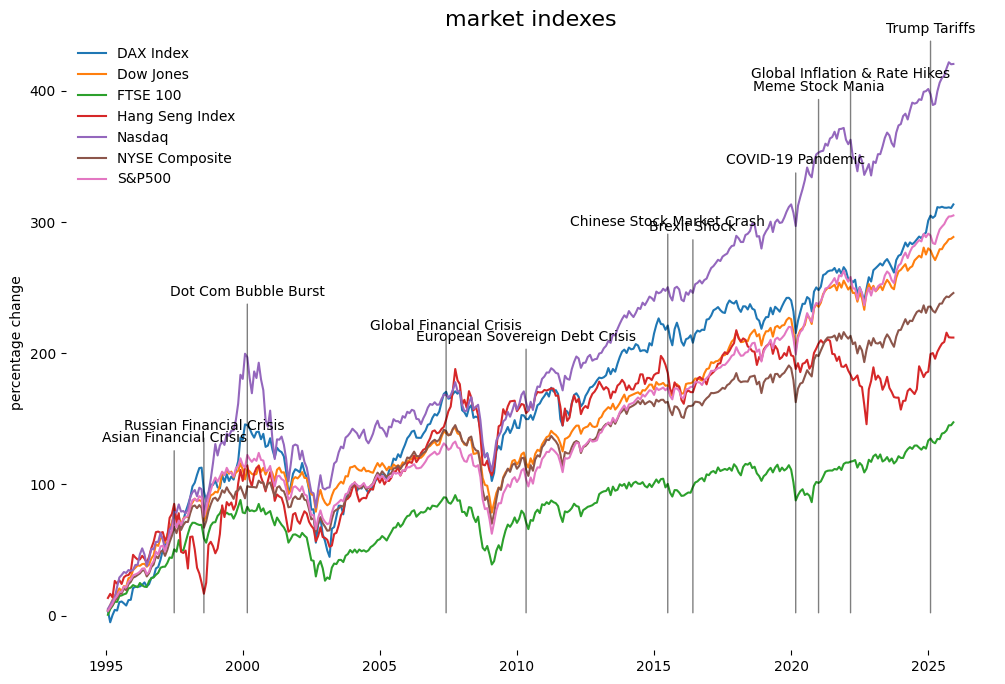

In [25]:
#  Last available value in each month
yf_30yr_monthly = yf_market_data.resample('ME').last()

#yf_30yr_monthly.index = pd.to_datetime(yf_30yr_monthly.index)
yf_30yr_monthly.index = yf_30yr_monthly.index.strftime('%Y-%m')

#  set XTICKS dates ticks and labels 
xticks_ticks = [f'{x}-01' for x in range(1995, 2026, 5)]
xticks_label = [x.split('-')[0] for x in xticks_ticks]


#  FINANCIAL EVENTS PLOT - market indexes - percent change
#--------------------------
#  get market indexes only
mrktIdx = yf_symbol_data['NAME'][yf_symbol_data['TYPE'] == 'Market Index'].tolist()

#  percent change data
yf_30yr_monthly_pct = yf_30yr_monthly.pct_change(fill_method=None).cumsum()*100

#  main plot of the notebook, with financial events
plt.figure(figsize= (12, 8))
sns.lineplot(yf_30yr_monthly_pct[mrktIdx], dashes = False)
plt.title('market indexes', fontsize = 16)
plt.xlabel('')
plt.ylabel('percentage change')
plt.xticks(xticks_ticks, xticks_label)
plt.legend(frameon = False)
plt.box(False)

# annotate text on lineplot
for event_date, event in zip(yf_finance_evt['DATE'], yf_finance_evt['FINANCIAL EVENT']):
    x = event_date
    y = yf_30yr_monthly_pct[mrktIdx].loc[yf_30yr_monthly_pct.index == event_date].max(axis = 1).values[0]
    plt.annotate(event, xytext = (x, y+50), xy = (x, 0), arrowprops = dict(arrowstyle = "-", alpha = 0.5), ha = 'center', va = 'center')
plt.show()
#--------------------------

[go to top of document](#top)     

---

# END